## Brain Tumor Classification From MRI Scans

This assignment implements a complete pipeline for brain tumor detection and
segmentation from MRI scans. We explore multiple deep learning architectures and
compare their performance using clinical metrics The work demonstrates proper
medical image preprocessing, data augmentation strategies, and clinical
evaluation methodologies.

DATASET:
Brain Tumor MRI Dataset from Kaggle
- 4 classes: Glioma, Meningioma, Pituitary Tumor, No Tumor
- ~7000 MRI images across train/test splits
- Grayscale images of varying dimensions

LEARNING OBJECTIVES:
1. Understand medical image preprocessing and normalization
2. Implement multiple CNN architectures from scratch and via transfer learning
3. Apply proper data augmentation for medical imaging
4. Evaluate models using clinical metrics (sensitivity, specificity, AUC)
5. Interpret model decisions using Grad-CAM visualization
6. Compare architectural choices and their trade-offs

In [1]:
print("=" * 80)
print("SECTION 1: ENVIRONMENT SETUP")
print("=" * 80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    roc_auc_score, accuracy_score, precision_recall_fscore_support
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import cv2
import os
import warnings
from tqdm.notebook import tqdm
import time
from collections import Counter

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")
print(f"✓ TensorFlow version: {tf.__version__}")
print(f"✓ GPU Available: {tf.config.list_physical_devices('GPU')}")
print()

SECTION 1: ENVIRONMENT SETUP
✓ Libraries imported successfully
✓ TensorFlow version: 2.20.0
✓ GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



In [2]:


from google.colab import files

print("=" * 80)
print("SECTION 2: DATASET DOWNLOAD & EXTRACTION")
print("=" * 80)

# Install KaggleHub (only first time)
!pip -q install kagglehub

import kagglehub
import os
import shutil

print("Downloading Brain Tumor MRI Dataset from Kaggle...")
print()

# Download dataset automatically
dataset_path = kagglehub.dataset_download(
    "masoudnickparvar/brain-tumor-mri-dataset"
)

print("✓ Dataset downloaded successfully!")
print(f"Location: {dataset_path}")

# Create the same folder structure expected by the rest of the notebook
destination = "brain_tumor_data"

if not os.path.exists(destination):
    shutil.copytree(dataset_path, destination)

print()
print("✓ Dataset ready!")
print("Training Folder :", os.path.join(destination, "Training"))
print("Testing Folder  :", os.path.join(destination, "Testing"))
print()


SECTION 2: DATASET DOWNLOAD & EXTRACTION

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
✓ Dataset downloaded successfully!
Location: /kaggle/input/brain-tumor-mri-dataset

✓ Dataset ready!
Training Folder : brain_tumor_data/Training
Testing Folder  : brain_tumor_data/Testing



Medical imaging preprocessing is crucial for model performance. According to
Menze et al. (2015) in the BraTS challenge paper, standardization across
different MRI scanners and protocols requires:
1. Intensity normalization (z-score or min-max)
2. Skull stripping (when working with raw DICOM)
3. Registration to common anatomical template
4. Resampling to consistent resolution

For this assignment, we'll focus on intensity normalization and augmentation
since our dataset is already preprocessed.

In [3]:
DATA_DIR = 'brain_tumor_data'
TRAIN_DIR = os.path.join(DATA_DIR, 'Training')
TEST_DIR = os.path.join(DATA_DIR, 'Testing')

# Image parameters
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32
NUM_CLASSES = 4
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

EXPLORATORY DATA ANALYSIS
-------------------------
Understanding the dataset is critical before modeling. We need to:
1. Check class distribution (potential imbalance)
2. Analyze image dimensions and quality
3. Visualize sample images from each class
4. Identify preprocessing requirements

Training Set Distribution:
  glioma         : 1400 images
  meningioma     : 1400 images
  notumor        : 1400 images
  pituitary      : 1400 images
  TOTAL          : 5600 images

Testing Set Distribution:
  glioma         :  400 images
  meningioma     :  400 images
  notumor        :  400 images
  pituitary      :  400 images
  TOTAL          : 1600 images



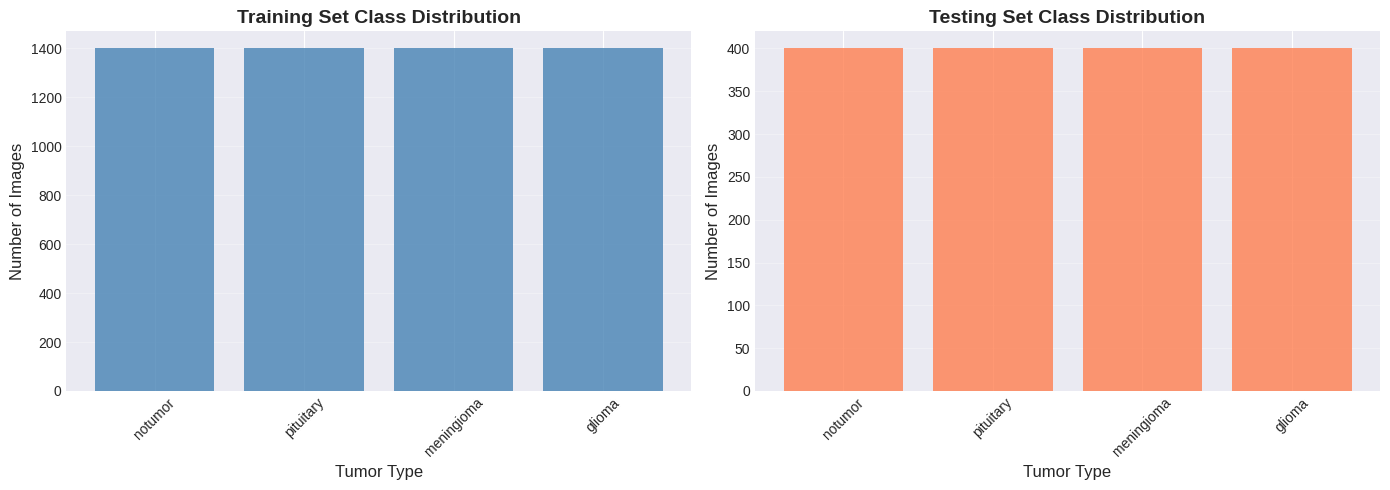

📊 Observation: Check if classes are balanced or if we need class weights



In [4]:
def count_images_per_class(data_dir):
    """Count images in each class directory"""
    class_counts = {}
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            count = len([f for f in os.listdir(class_path)
                        if f.endswith(('.jpg', '.png', '.jpeg'))])
            class_counts[class_name] = count
    return class_counts

train_counts = count_images_per_class(TRAIN_DIR)
test_counts = count_images_per_class(TEST_DIR)

print("Training Set Distribution:")
for class_name, count in sorted(train_counts.items()):
    print(f"  {class_name:15s}: {count:4d} images")
print(f"  {'TOTAL':15s}: {sum(train_counts.values()):4d} images")
print()

print("Testing Set Distribution:")
for class_name, count in sorted(test_counts.items()):
    print(f"  {class_name:15s}: {count:4d} images")
print(f"  {'TOTAL':15s}: {sum(test_counts.values()):4d} images")
print()

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training distribution
axes[0].bar(train_counts.keys(), train_counts.values(), color='steelblue', alpha=0.8)
axes[0].set_title('Training Set Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tumor Type', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Testing distribution
axes[1].bar(test_counts.keys(), test_counts.values(), color='coral', alpha=0.8)
axes[1].set_title('Testing Set Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tumor Type', fontsize=12)
axes[1].set_ylabel('Number of Images', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("📊 Observation: Check if classes are balanced or if we need class weights")
print()

CLINICAL INSIGHT 1: Class Imbalance
------------------------------------
In medical imaging, class imbalance is common and clinically significant:
- Rare tumors may have fewer samples
- "No tumor" cases might be overrepresented in screening datasets
- Imbalance requires special handling: class weights, focal loss, or SMOTE

We'll compute class weights to handle this during training.


 Data Augmentation in Medical Imaging
---------------------------------------------------------------
Data augmentation is crucial but must be clinically appropriate:
- Rotation: ✓ (brain orientation can vary in imaging)
- Horizontal flip: ✓ (left/right hemisphere)
- Vertical flip: ✗ (not anatomically realistic)
- Zoom/scaling: ✓ (different tumor sizes)
- Brightness/contrast: ✓ (scanner variations)
- Extreme distortions: ✗ (unrealistic artifacts)

Reference: Shorten & Khoshgoftaar (2019) - "A survey on Image Data Augmentation
for Deep Learning" emphasizes domain-specific augmentation strategies.
"""

🔄 Setting up data augmentation pipeline...
Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
✓ Training samples: 4760
✓ Validation samples: 840
✓ Test samples: 1600
✓ Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

📸 Visualizing augmentation effects...


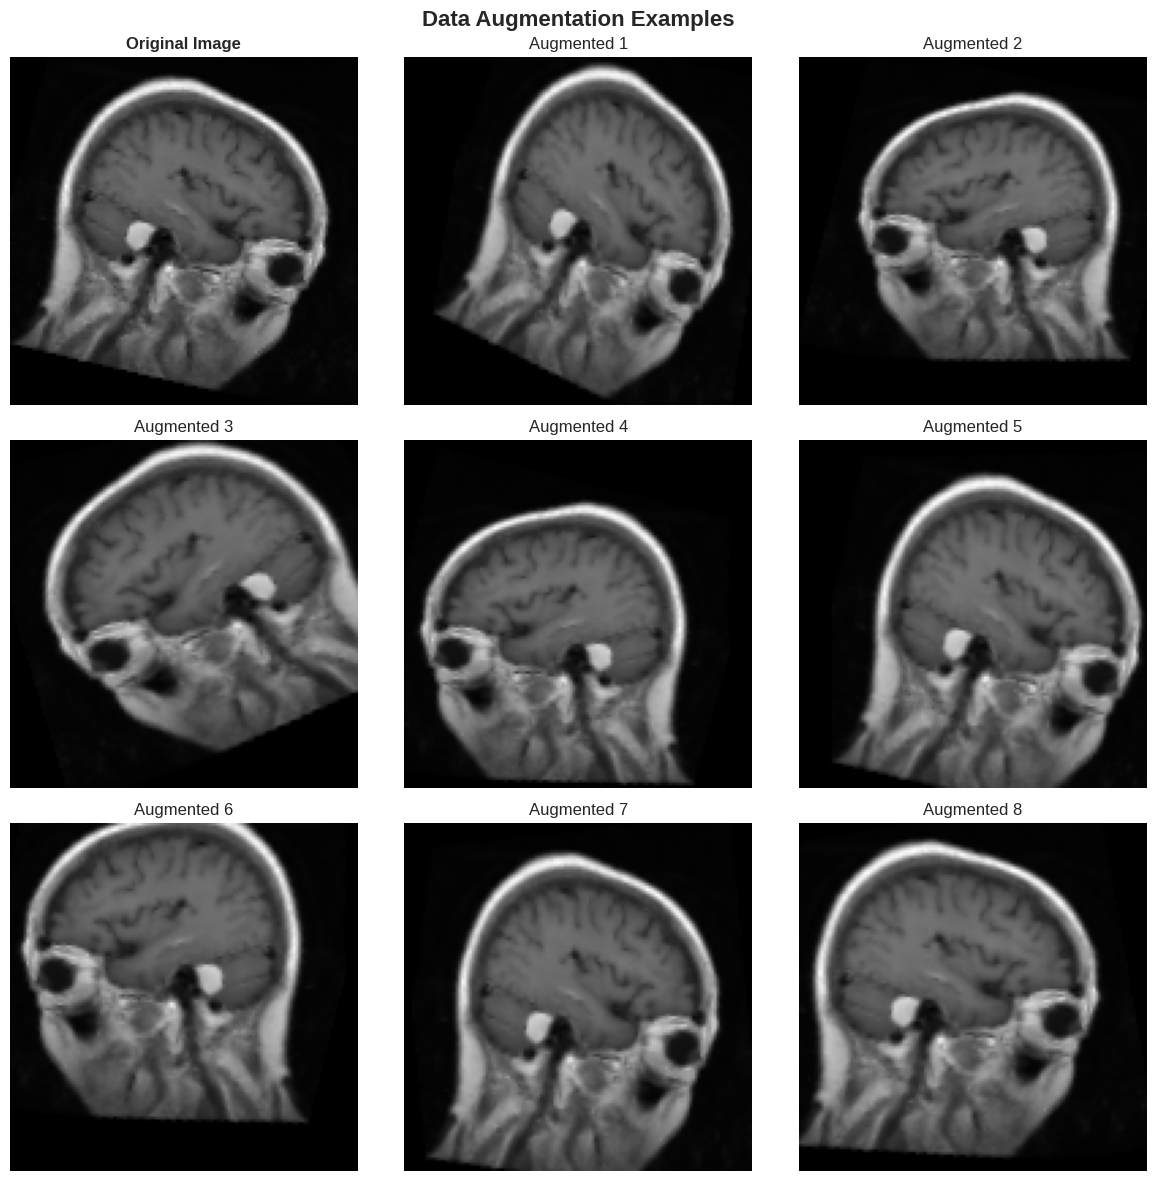

✓ Augmentation visualization complete

⚖️ Computing class weights for imbalanced data...
Class weights:
  glioma         : 1.000
  meningioma     : 1.000
  notumor        : 1.000
  pituitary      : 1.000



In [5]:
print("🔄 Setting up data augmentation pipeline...")

# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,                    # Normalize to [0,1]
    rotation_range=15,                 # Random rotation ±15°
    width_shift_range=0.1,             # Horizontal shift
    height_shift_range=0.1,            # Vertical shift
    shear_range=0.1,                   # Shear transformation
    zoom_range=0.15,                   # Random zoom
    horizontal_flip=True,              # Random horizontal flip
    fill_mode='constant',              # Fill with zeros
    cval=0,                            # Fill value
    validation_split=0.15              # 15% for validation
)

# Test data generator (only rescaling, no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training data with augmentation
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=True,
    subset='training',
    seed=42
)

# Load validation data (from training split, no augmentation in validation)
validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=False,
    subset='validation',
    seed=42
)

# Load test data
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=False
)

print(f"✓ Training samples: {train_generator.samples}")
print(f"✓ Validation samples: {validation_generator.samples}")
print(f"✓ Test samples: {test_generator.samples}")
print(f"✓ Class indices: {train_generator.class_indices}")
print()
print("📸 Visualizing augmentation effects...")

sample_batch = next(iter(train_generator))
original_image = sample_batch[0][0]  # First image from batch

# Generate augmented versions
augmented_images = []
temp_gen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='constant'
)

# Create multiple augmented versions
img_array = np.expand_dims(original_image, 0)
aug_iter = temp_gen.flow(img_array * 255, batch_size=1)  # Rescale back
for i in range(8):
    aug_img = next(aug_iter)[0].astype('uint8')
    augmented_images.append(aug_img)

# Plot original and augmented
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('Data Augmentation Examples', fontsize=16, fontweight='bold')

axes[0, 0].imshow(original_image.squeeze(), cmap='gray')
axes[0, 0].set_title('Original Image', fontweight='bold')
axes[0, 0].axis('off')

for idx, aug_img in enumerate(augmented_images):
    row = (idx + 1) // 3
    col = (idx + 1) % 3
    axes[row, col].imshow(aug_img.squeeze(), cmap='gray')
    axes[row, col].set_title(f'Augmented {idx+1}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Augmentation visualization complete")
print()

# Compute class weights for handling imbalance
print("⚖️ Computing class weights for imbalanced data...")

class_counts_array = np.array([train_counts[cn] for cn in sorted(CLASS_NAMES)])
total_samples = np.sum(class_counts_array)
class_weights = total_samples / (NUM_CLASSES * class_counts_array)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print("Class weights:")
for i, (class_name, weight) in enumerate(zip(sorted(CLASS_NAMES), class_weights)):
    print(f"  {class_name:15s}: {weight:.3f}")
print()

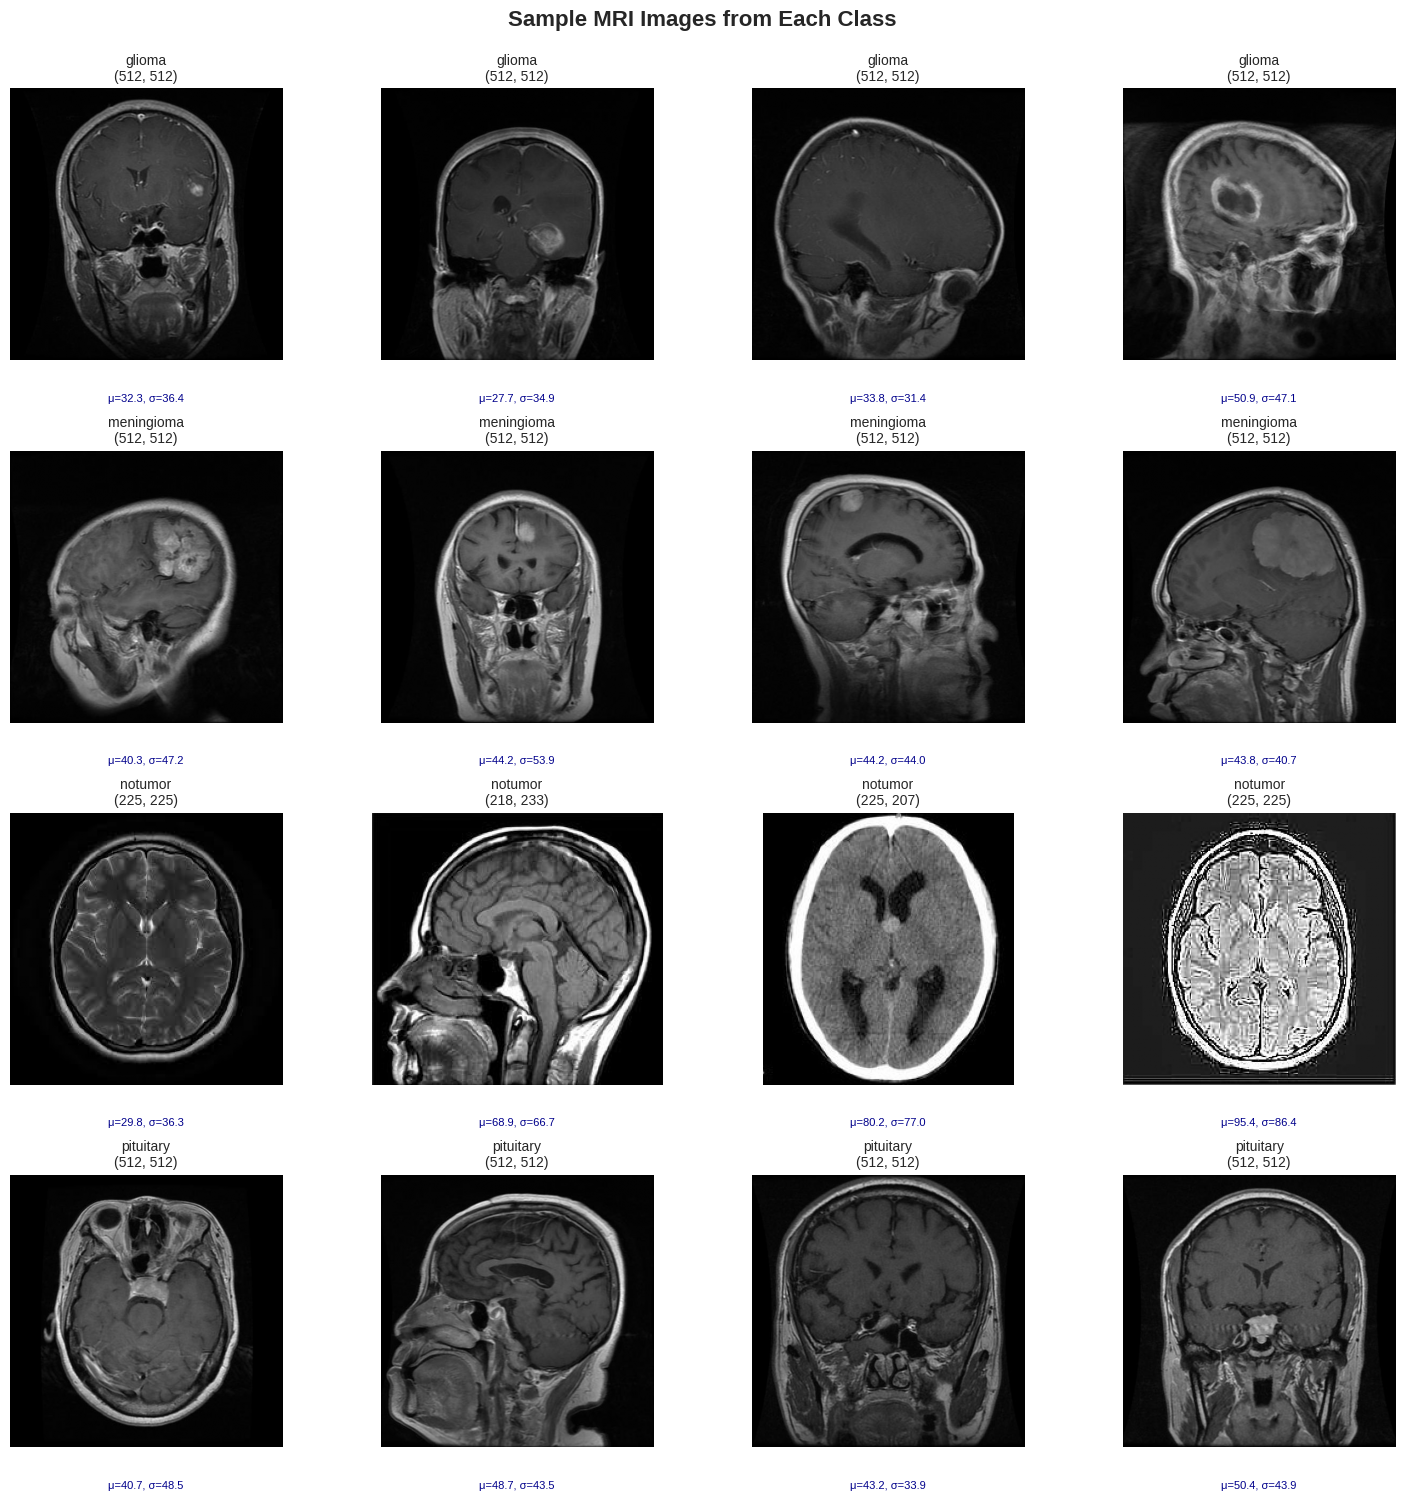

🔍 Key Observations:
  - Image dimensions vary (need resizing)
  - Intensity ranges differ (need normalization)
  - Different contrast levels (augmentation will help)

📏 Analyzing image dimensions (sampling 200 images)...
  Found 42 unique dimensions (from sample)
  Most common dimensions:
    (512, 512): 4012 images
    (225, 225): 253 images
    (630, 630): 69 images
    (251, 201): 40 images
    (236, 236): 39 images
  → Standardizing to 128x128 for consistent processing



In [6]:
# Display sample images from each class
def load_sample_images(data_dir, samples_per_class=3):
    """Load sample images from each class"""
    samples = {}
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            image_files = [f for f in os.listdir(class_path)
                          if f.endswith(('.jpg', '.png', '.jpeg'))]
            sample_files = np.random.choice(image_files,
                                           min(samples_per_class, len(image_files)),
                                           replace=False)
            images = []
            for img_file in sample_files:
                img_path = os.path.join(class_path, img_file)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                images.append(img)
            samples[class_name] = images
    return samples

sample_images = load_sample_images(TRAIN_DIR, samples_per_class=4)

# Plot sample images
fig, axes = plt.subplots(4, 4, figsize=(15, 15))
fig.suptitle('Sample MRI Images from Each Class', fontsize=16, fontweight='bold', y=0.995)

for idx, (class_name, images) in enumerate(sorted(sample_images.items())):
    for i, img in enumerate(images):
        axes[idx, i].imshow(img, cmap='gray')
        axes[idx, i].set_title(f'{class_name}\n{img.shape}', fontsize=10)
        axes[idx, i].axis('off')

        # Add simple statistics
        mean_intensity = np.mean(img)
        std_intensity = np.std(img)
        axes[idx, i].text(0.5, -0.15, f'μ={mean_intensity:.1f}, σ={std_intensity:.1f}',
                         transform=axes[idx, i].transAxes,
                         ha='center', fontsize=8, color='darkblue')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=300, bbox_inches='tight')
plt.show()

print("🔍 Key Observations:")
print("  - Image dimensions vary (need resizing)")
print("  - Intensity ranges differ (need normalization)")
print("  - Different contrast levels (augmentation will help)")
print()

def analyze_image_dimensions(data_dir):
    """Analyze distribution of image dimensions"""
    dimensions = []
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            for img_file in os.listdir(class_path):
                if img_file.endswith(('.jpg', '.png', '.jpeg')):
                    img_path = os.path.join(class_path, img_file)
                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    dimensions.append(img.shape)
    return dimensions

print("📏 Analyzing image dimensions (sampling 200 images)...")
all_dims = analyze_image_dimensions(TRAIN_DIR)
sampled_dims = np.random.choice(len(all_dims), min(200, len(all_dims)), replace=False)
unique_dims = set([all_dims[i] for i in sampled_dims])

print(f"  Found {len(unique_dims)} unique dimensions (from sample)")
print(f"  Most common dimensions:")
dim_counter = Counter(all_dims)
for dim, count in dim_counter.most_common(5):
    print(f"    {dim}: {count} images")
print(f"  → Standardizing to {IMG_HEIGHT}x{IMG_WIDTH} for consistent processing")
print()

In [7]:
# ============================================================
# TRANSFER LEARNING DATA PIPELINE (RGB + MobileNetV2 preprocess)
# ============================================================

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("🔄 Setting up TRANSFER LEARNING generators (RGB + preprocess_input)...")

# IMPORTANT:
# - Do NOT use rescale=1./255 when using preprocess_input for MobileNetV2.
# - preprocess_input expects raw pixels in [0, 255] and normalizes internally.

train_datagen_tl = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='constant',
    cval=0,
    validation_split=0.15
)

test_datagen_tl = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator_tl = train_datagen_tl.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb',         # <-- key difference vs baseline
    shuffle=True,
    subset='training',
    seed=1
)

validation_generator_tl = train_datagen_tl.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    subset='validation',
    seed=1
)

test_generator_tl = test_datagen_tl.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

print(f"✓ TL Training samples: {train_generator_tl.samples}")
print(f"✓ TL Validation samples: {validation_generator_tl.samples}")
print(f"✓ TL Test samples: {test_generator_tl.samples}")
print(f"✓ TL Class indices: {train_generator_tl.class_indices}")
print()

# Sanity check: class order should match baseline (so comparisons are valid)
assert train_generator.class_indices == train_generator_tl.class_indices, \
    "Class index mapping differs between baseline and TL generators."
print("✓ Class index mapping matches baseline.")


🔄 Setting up TRANSFER LEARNING generators (RGB + preprocess_input)...
Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
✓ TL Training samples: 4760
✓ TL Validation samples: 840
✓ TL Test samples: 1600
✓ TL Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

✓ Class index mapping matches baseline.
